In [ ]:
import os

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


%matplotlib inline

In [11]:
df = pd.read_csv("seasonal_agriculture_performance_dataset 2.csv")


In [12]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [13]:
df.shape

(4000, 28)

In [14]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [16]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [17]:
df.nunique()

Farm_ID                          4000
State                               8
District                           10
Crop                                8
Season                              3
Farm_Area_Hectares               1370
Rainfall_mm                      3256
Avg_Temperature_C                 204
Humidity_pct                      573
Sunlight_Hours_Day                 71
Soil_pH                           313
Soil_Moisture_pct                 343
Nitrogen_kg_ha                   1229
Phosphorus_kg_ha                  760
Potassium_kg_ha                  1137
Irrigation_Method                   4
Fertilizer_kg_ha                 1881
Pesticide_Litre_ha                851
Seed_Quality_Score                 36
Yield_Tonnes_Ha                   738
Production_Tonnes                2528
Market_Price_INR_Tonne           3760
Total_Cost_INR                   3995
Revenue_INR                      3993
Profit_INR                       3992
Water_Used_m3                    3407
Water_Effici

In [18]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [19]:
missing = df.isnull().sum()

missing_percentage = (
    missing / len(df) * 100
).sort_values(ascending=False)

missing_percentage

Rainfall_mm                      1.2
Soil_Moisture_pct                1.0
Yield_Tonnes_Ha                  0.8
Farm_ID                          0.0
Crop                             0.0
District                         0.0
Farm_Area_Hectares               0.0
Season                           0.0
Avg_Temperature_C                0.0
Humidity_pct                     0.0
Sunlight_Hours_Day               0.0
State                            0.0
Soil_pH                          0.0
Nitrogen_kg_ha                   0.0
Potassium_kg_ha                  0.0
Phosphorus_kg_ha                 0.0
Irrigation_Method                0.0
Fertilizer_kg_ha                 0.0
Pesticide_Litre_ha               0.0
Seed_Quality_Score               0.0
Production_Tonnes                0.0
Market_Price_INR_Tonne           0.0
Total_Cost_INR                   0.0
Revenue_INR                      0.0
Profit_INR                       0.0
Water_Used_m3                    0.0
Water_Efficiency_t_per_1000m3    0.0
D

In [20]:
numeric_missing = [
    'Rainfall_mm',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha'
]

for col in numeric_missing:
    df[col] = df[col].fillna(df[col].median())

In [21]:
df.isnull().sum().sum()

np.int64(0)

In [22]:
df['Season'].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns


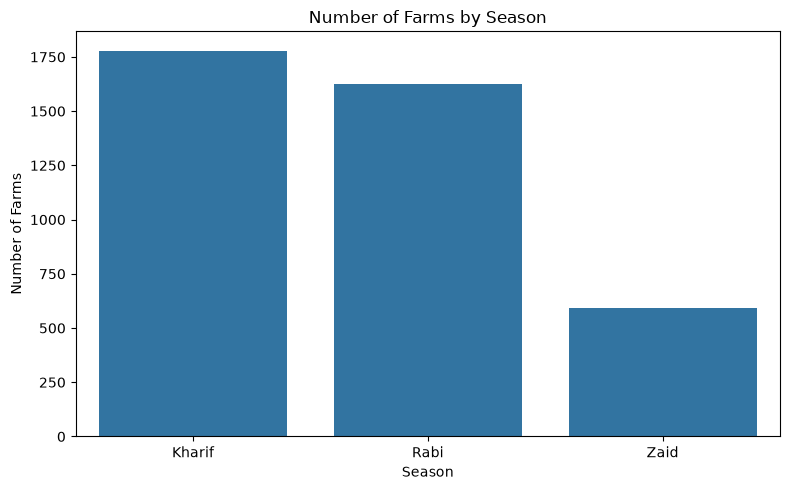

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Season')

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.tight_layout()
plt.show()

In [25]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
})

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,
Kharif,5.628612,46.311192,710719.055649,178914.647555,5.891834,54.467903
Rabi,5.039435,41.486712,601526.048556,87689.470191,5.186122,40.482114
Zaid,4.641313,38.886111,519171.904040,-24804.824916,4.413239,38.216667


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

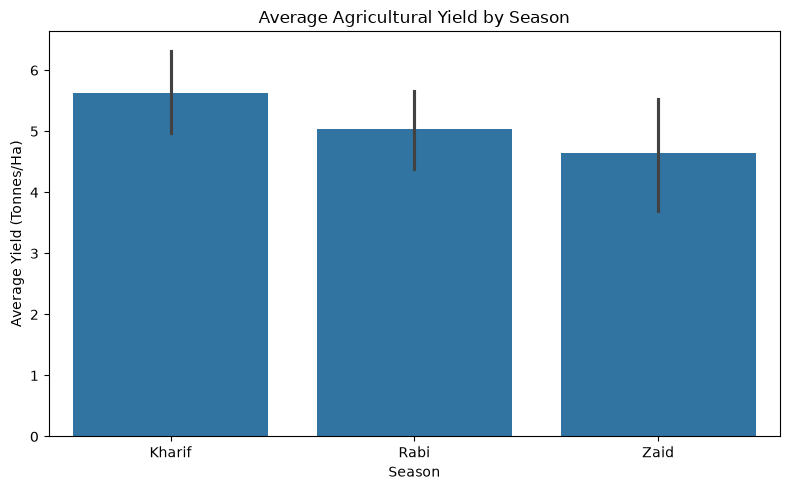

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

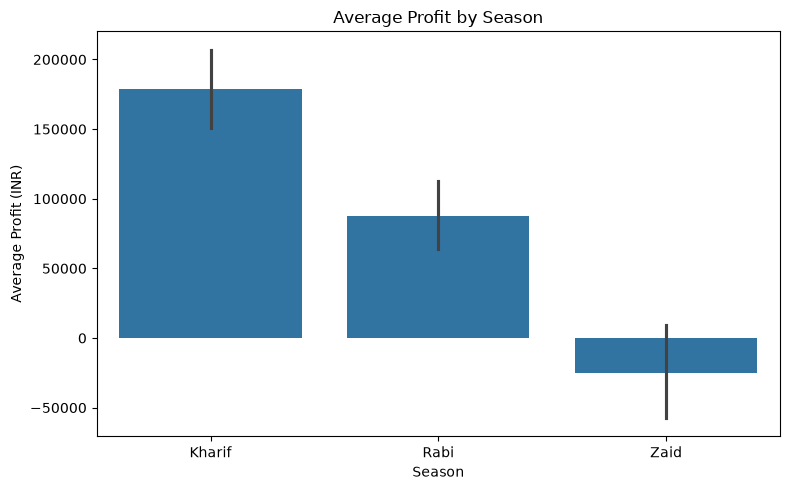

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    estimator='mean'
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.tight_layout()
plt.show()

In [29]:
df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64

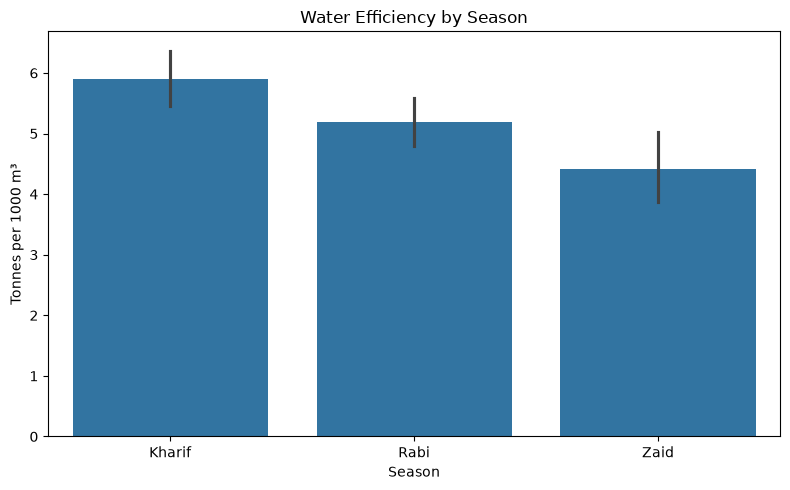

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Efficiency_t_per_1000m3'
)

plt.title('Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Tonnes per 1000 m³')
plt.tight_layout()
plt.show()

In [31]:
df.groupby('Season')['Rainfall_mm'].mean()

Season
Kharif    849.199663
Rabi      437.615366
Zaid      304.654714
Name: Rainfall_mm, dtype: float64

In [32]:
df.groupby('Season')['Avg_Temperature_C'].mean()

Season
Kharif    28.454019
Rabi      23.489183
Zaid      31.042088
Name: Avg_Temperature_C, dtype: float64

In [33]:
df.groupby('Season')['Humidity_pct'].mean()

Season
Kharif    71.812591
Rabi      57.893178
Zaid      52.012121
Name: Humidity_pct, dtype: float64

In [34]:
df.groupby('Season')['Soil_Moisture_pct'].mean()

Season
Kharif    31.149859
Rabi      24.069392
Zaid      19.279630
Name: Soil_Moisture_pct, dtype: float64

In [35]:
environment_summary = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean'
})

environment_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.199663,28.454019,71.812591,6.793367,31.149859
Rabi,437.615366,23.489183,57.893178,7.589797,24.069392
Zaid,304.654714,31.042088,52.012121,8.178788,19.279630


In [37]:
df['Crop'].value_counts()

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

In [38]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean()

crop_yield.sort_values(ascending=False)

Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64

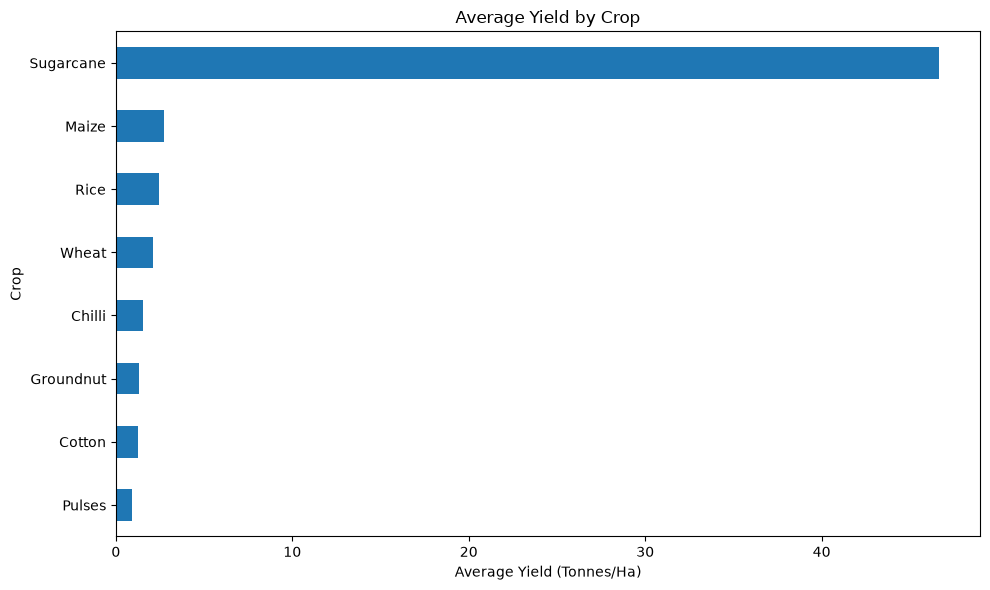

In [39]:
plt.figure(figsize=(10,6))

crop_yield.sort_values().plot(kind='barh')

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

In [40]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean()

crop_profit.sort_values(ascending=False)

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64

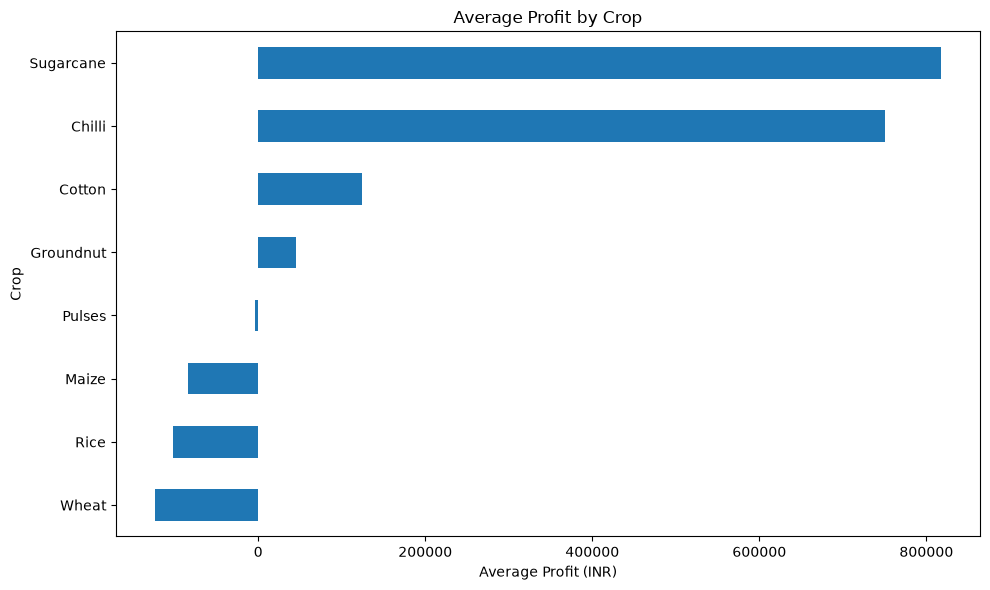

In [41]:
plt.figure(figsize=(10,6))

crop_profit.sort_values().plot(kind='barh')

plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

In [42]:
df['Irrigation_Method'].value_counts()

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

In [43]:
df.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha':'mean',
    'Profit_INR':'mean',
    'Water_Efficiency_t_per_1000m3':'mean'
})

,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,
Drip,6.577989,219625.997814,6.267129
Flood,4.863977,73354.022901,3.438853
Rainfed,4.602142,79050.365034,7.563784
Sprinkler,5.160627,91121.079019,4.669805


In [44]:
df.groupby('Season')['Fertilizer_kg_ha'].mean()

Season
Kharif    187.077965
Rabi      185.407068
Zaid      184.638047
Name: Fertilizer_kg_ha, dtype: float64

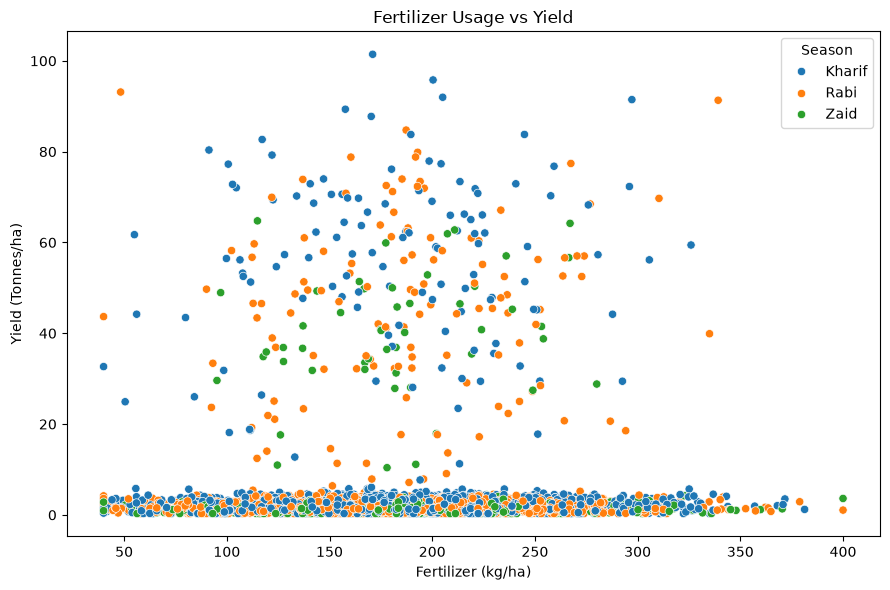

In [45]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Fertilizer Usage vs Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/ha)')
plt.tight_layout()
plt.show()

In [46]:
df.groupby('Season')['Disease_Pest_Risk_pct'].mean()




Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64

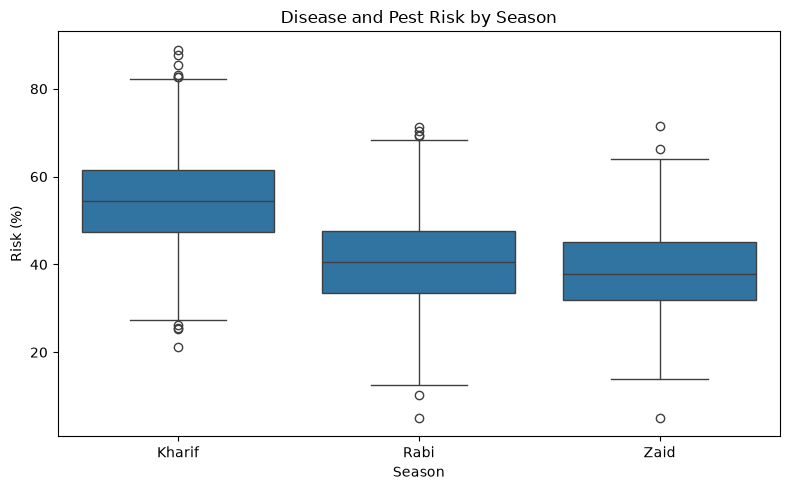

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct'
)

plt.title('Disease and Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Risk (%)')
plt.tight_layout()
plt.show()

In [48]:
df.groupby('Season')['Water_Used_m3'].mean()

Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64

In [49]:
df.groupby('Irrigation_Method').agg({
    'Water_Used_m3':'mean',
    'Yield_Tonnes_Ha':'mean',
    'Water_Efficiency_t_per_1000m3':'mean'
})

,Water_Used_m3,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,
Drip,5918.747541,6.577989,6.267129
Flood,8026.472519,4.863977,3.438853
Rainfed,3549.554275,4.602142,7.563784
Sprinkler,6208.258856,5.160627,4.669805


In [50]:
numeric_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

corr = df[numeric_cols].corr()

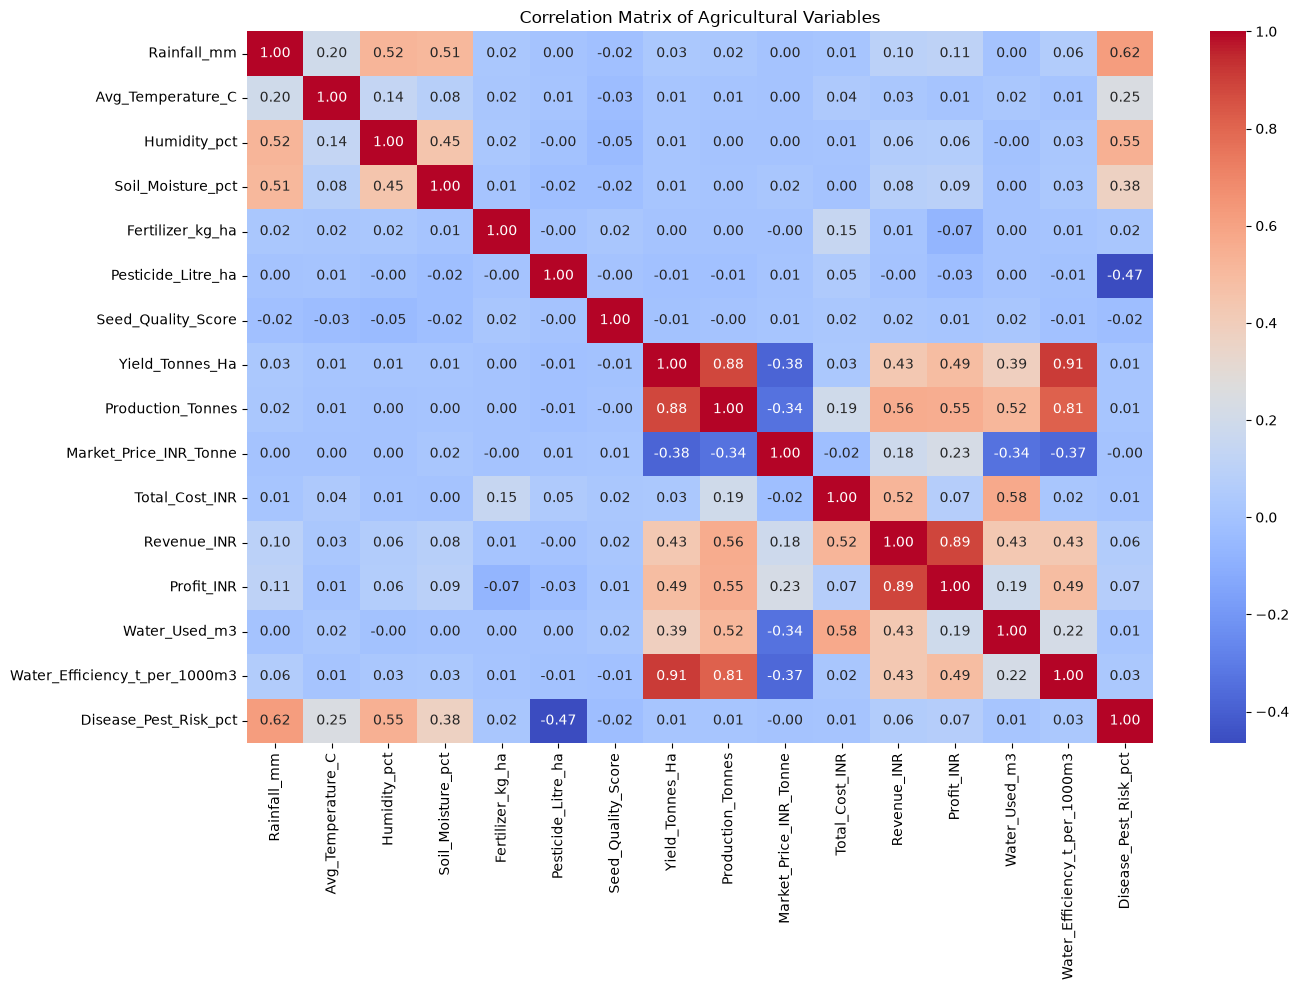

In [51]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Agricultural Variables')
plt.tight_layout()
plt.show()

In [52]:
df['Profit_Status'] = np.where(
    df['Profit_INR'] > 0,
    'Profitable',
    'Loss'
)

In [53]:
df['Profit_Status'].value_counts()

Profit_Status
Profitable    2034
Loss          1966
Name: count, dtype: int64

In [54]:
pd.crosstab(
    df['Season'],
    df['Profit_Status'],
    normalize='index'
) * 100

Profit_Status,Loss,Profitable
Season,,
Kharif,42.214727,57.785273
Rabi,51.137062,48.862938
Zaid,64.478114,35.521886
